## Test for YoloV4-Tiny

In [1]:
!pip install opencv-python numpy urllib3

Ensure Yolo Model is installed:

In [ ]:
import cv2
import numpy as np

# Loads YOLO model
net = cv2.dnn.readNet("/Users/jfm/A3_system_project/drakos-dynamics-c2-tse/A3_System/models/yolo/yolov4-tiny.weights",
                      "/Users/jfm/A3_system_project/drakos-dynamics-c2-tse/A3_System/models/yolo/yolov4-tiny.cfg")
classes = open("/Users/jfm/A3_system_project/drakos-dynamics-c2-tse/A3_System/models/yolo/coco.names").read().strip().split("\n")

print("YOLOv4-Tiny model loaded successfully!")


YOLOv4-Tiny model loaded successfully!


In [7]:
import os
import cv2
import numpy as np
from PIL import Image
from IPython.display import display


relative_path = "../data/ball_in_grass.jpg"
image_path = os.path.abspath(relative_path) 

image_original = cv2.imread(image_path)

if image_original is None:
    raise ValueError(f"Image loading failed. Check the file format or path: {image_path}")

print("Image loaded")


Image loaded


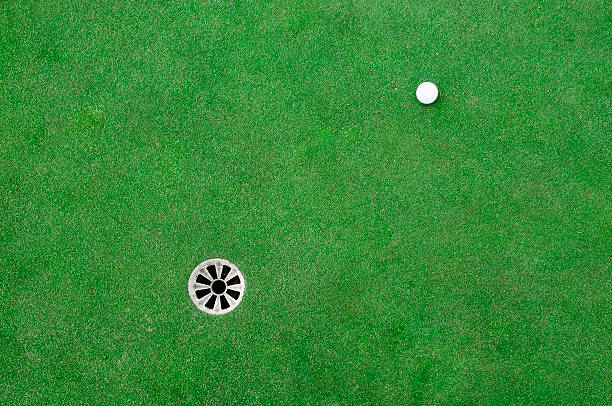

In [8]:
import urllib.request
from IPython.display import display
from PIL import Image

# display (Ball in Grass)
image_path = "../data/ball_in_grass.jpg"  
img = Image.open(image_path)
display(img)


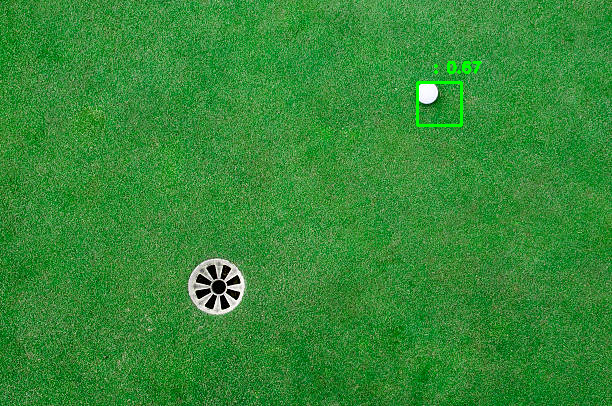

In [ ]:
image_original = cv2.imread(image_path)

# Ensure the image loads properly
if image_original is None:
    raise ValueError(f"Error: OpenCV failed to load the image. Check the file format or path: {image_path}")

image = image_original.copy()

''' The YOLO work will begin here by first ensuring that the image is converted for YOLO input:'''
blob = cv2.dnn.blobFromImage(image_original, 0.00392, (416, 416), swapRB=True, crop=False)
net.setInput(blob)

# Getting YOLO output layer names
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Object detection
detections = net.forward(output_layers)

# bounding boxes
boxes = []
confidences = []
class_ids = []

for output in detections:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.2:  # Lower confidence to detect smaller objects
            x, y, w, h = (detection[:4] * [image.shape[1], image.shape[0], image.shape[1], image.shape[0]]).astype("int")
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Max Suppression (NMS)
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.2, 0.6)

# Check if there are valid detections
if indices is not None and len(indices) > 0:
    indices = indices.flatten()  # Convert to list
    
    # Keep only the highest confidence detection
    best_index = indices[0]  
    
    # Extracting only the good bounding boxes
    x, y, w, h = boxes[best_index]
    
    # Expand the bounding box to account for space of ball
    padding = 10
    x, y, w, h = max(x - padding, 0), max(y - padding, 0), w + 2 * padding, h + 2 * padding

    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)  # Green box
    label = f"{classes[class_ids[best_index]]}: {confidences[best_index]:.2f}"
    cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    
else:
    print("No valid detections found after NMS.")

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

display(Image.fromarray(image_rgb))
